# Illustrative Case Study Application for OQ-VMTK

## Introduction

This Jupyter Notebook is the electronic supplement to the example provided in the *Illustrative Case Study Application for OQ-VMTK* section of the companion EQ Spectra paper.

This Jupyter Notebook provides a step-by-step workflow that takes a single-degree-of-freedom (SDOF) capacity curve and derives a structural vulnerability function for the corresponding building class. A multi-degree-of-freedom (MDOF) stick-and-mass model is calibrated from the SDOF capacity, verified through modal and pushover analyses, and then subjected to nonlinear time-history analyses (NLTHA) using natural unscaled ground-motion records (Modified Cloud Analysis). The resulting demands are post-processed into fragility and vulnerability functions. 

The main goals of this notebook:

1. **Calibrate and compile an MDOF model**: derive storey-based force-deformation backbones from the SDOF capacity curve using `calibrate_model` and compile the model in OpenSeesPy using the `modeller` module.

2. **Verify the model**: run a modal analysis to extract periods and mode shapes, and a static (monotonic) pushover analysis to check the global capacity of the model.

3. **Run Modified Cloud Analysis**: perform NLTHA over a suite of ground-motion records and extract engineering demand parameters (peak storey drifts, floor accelerations and displacements).

4. **Derive fragility functions**: fit a probabilistic seismic demand model and derive fragility functions with the `postprocessor` module (bootstrap and classical Bayesian MCMC approaches).

5. **Derive vulnerability functions**: convolve fragility functions with a damage-to-loss consequence model, including uncertainty propagation.

6. **Visualise the results** at every stage using the `plotter` module.

The modules used in this notebook are `calibration`, `modeller`, `postprocessor`, `plotter`, `units` and `utilities`.

---

## References

[1] Jalayer, F., De Risi, R. & Manfredi, G. Bayesian Cloud Analysis: efficient structural fragility assessment using linear regression. Bull Earthquake Eng 13, 1183–1203 (2015). https://doi.org/10.1007/s10518-014-9692-z

[2] Jalayer F, Ebrahimian H, Miano A, Manfredi G, Sezen H. Analytical fragility assessment using unscaled ground motion records. Earthquake Engng Struct Dyn. 2017; 46: 2639–2663. https://doi.org/10.1002/eqe.2922

[3] Miano A, Jalayer F, Ebrahimian H, Prota A. Cloud to IDA: Efficient fragility assessment with limited scaling. Earthquake Engng Struct Dyn. 2018; 47: 1124–1147. https://doi.org/10.1002/eqe.3009

[4] Lu X, McKenna F, Cheng Q, Xu Z, Zeng X, Mahin SA. An open-source framework for regional earthquake loss estimation using the city-scale nonlinear time history analysis. Earthquake Spectra. 2020;36(2):806-831. doi: 10.1177/8755293019891724


## Import Libraries ##

In [1]:
import os
import numpy as np
import pandas as pd

from openquake.vmtk.units import units
from openquake.vmtk.modeller import modeller
from openquake.vmtk.calibration import calibrate_model
from openquake.vmtk.postprocessor import postprocessor
from openquake.vmtk.plotter import plotter
from openquake.vmtk.utilities import sorted_alphanumeric, import_from_pkl, export_to_pkl, get_num_modes

## Calibrate and Compile an MDOF Model based on SDOF Capacity ##

### Define the Building Properties and SDOF Capacity ###

In [2]:
# Number of storeys
number_storeys = 4

# Relative floor heights list
storey_heights = [2.80, 2.80, 2.80, 2.80]

# SDOF capacity with a quadrilinear backbone
sdof_capacity = np.array(
    [
        [0.0018947368,
         0.0151578947,
         0.0545684211,
         0.1023157895],  # spectral displacement [in m]
       
        [0.1464945695,
         0.2929891390,
         0.1757934834,
         0.1775514182],     # spectral acceleration [in g]
    ]
).T  

# Soft-storey mechanism flag
is_sos = False

# Degradation flag
mdof_degradation = False

### Calibrate the MDOF Model ###

The `calibrate_model` function derives consistent per-storey force-deformation backbones directly from the SDOF spectral capacity curve. The calibration follows three steps:

1. **Period matching** — a mass matrix and relative stiffness profile are constructed from the building geometry, then scaled analytically so that the MDOF fundamental period matches T* = 2π√(Sd₀ / (Sa₀·g)), the period implied by the initial stiffness of the SDOF capacity curve.

2. **Backbone distribution** — the first mode shape and participation factors are used to distribute the SDOF base shear and roof displacement into per-storey shear and drift backbones, following displacement-based design principles [4]. A uniform-ductility assumption is applied so that all storeys share the same displacement backbone shape.

3. **Stiffness consistency** — storey forces are rescaled so that each backbone's implied stiffness is exactly consistent with the analytically scaled stiffness matrix, guaranteeing T* is reproduced in OpenSees without iterative correction.

The function returns `floor_masses`, `storey_drifts`, `storey_forces`, the first mode shape `mdof_phi`, and a `meta` dictionary containing modal properties and the target roof displacement array.

In [3]:
# Calibrate the model
floor_masses, storey_drifts, storey_forces, mdof_phi, meta = calibrate_model(
    number_storeys,
    sdof_capacity,
    is_sos=is_sos,
    storey_heights=storey_heights,
    verbose=False,
)

### Compile the MDOF Model ###

The `modeller` class assembles the calibrated OpenSees model using the per-storey properties derived by `calibrate_model`. It builds a vertical chain of zero-length spring elements — one per storey — each characterised by a Pinching4 hysteretic material. Unlike a manually specified model, `floor_masses`, `storey_drifts`, and `storey_forces` are not user-specified but flow directly from the calibration output, guaranteeing that the fundamental period and global capacity of this MDOF model are consistent with the reference SDOF system.

Note that `storey_forces` from `calibrate_model` are in g·tonnes and must be multiplied by `g` (9.81 m/s²) to convert to kN before passing to `modeller`.

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2003 has L= 2.8, which is greater than the tolerance


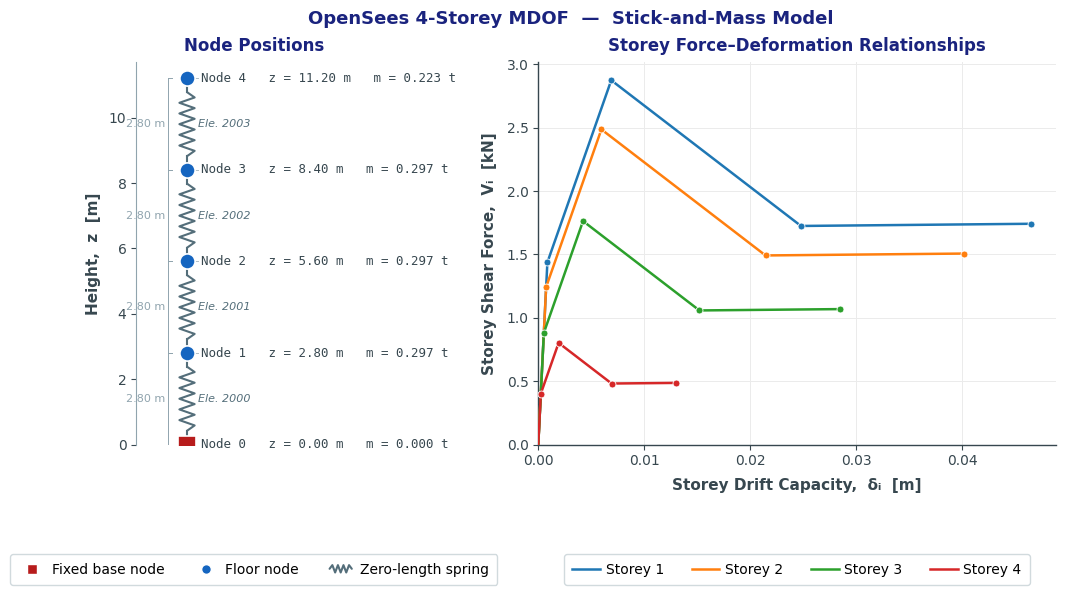

In [4]:
# Initialise the modeller class with calibration results
model = modeller(
    number_storeys,
    storey_heights,
    floor_masses,
    storey_drifts,
    storey_forces * units.g,
    mdof_degradation,
)

# Compile the MDOF model in OpenSeesPy
model.compile_model()

# Visualise the model
model.plot_model(pFlag=True, export_path="./out/mdof_model.png")

## Run Modal Analysis ##

After compiling the model, `do_modal_analysis` solves the generalised eigenvalue problem K·φ = ω²·M·φ to extract natural periods and mode shapes. Setting `pFlag=True` prints a modal summary to the console; `plot_modes=True` renders all extracted mode shapes against the undeformed stick geometry and saves the figure to `export_path` if provided.

Fundamental Period: T = 0.228 s


Using DomainModalProperties - Developed by: Massimo Petracca, Guido Camata, ASDEA Software Technology
# MODAL ANALYSIS REPORT

* 1. DOMAIN SIZE:
# This is the size of the problem: 1 for 1D problems, 2 for 2D problems, 3 for 3D problems.
3


* 2. EIGENVALUE ANALYSIS:
#          MODE        LAMBDA         OMEGA     FREQUENCY        PERIOD
# ------------- ------------- ------------- ------------- -------------
              1       758.476       27.5404        4.3832      0.228144
              2       758.476       27.5404        4.3832      0.228144
              3       6178.09       78.6008       12.5097     0.0799379
              4       6178.09       78.6008       12.5097     0.0799379


* 3. TOTAL MASS OF THE STRUCTURE:
# The total masses (translational and rotational) of the structure
# including the masses at fixed DOFs (if any).
#            MX            MY            MZ           RMX           RMY           RMZ
# ------------- ------------- ------------- ------------- -------

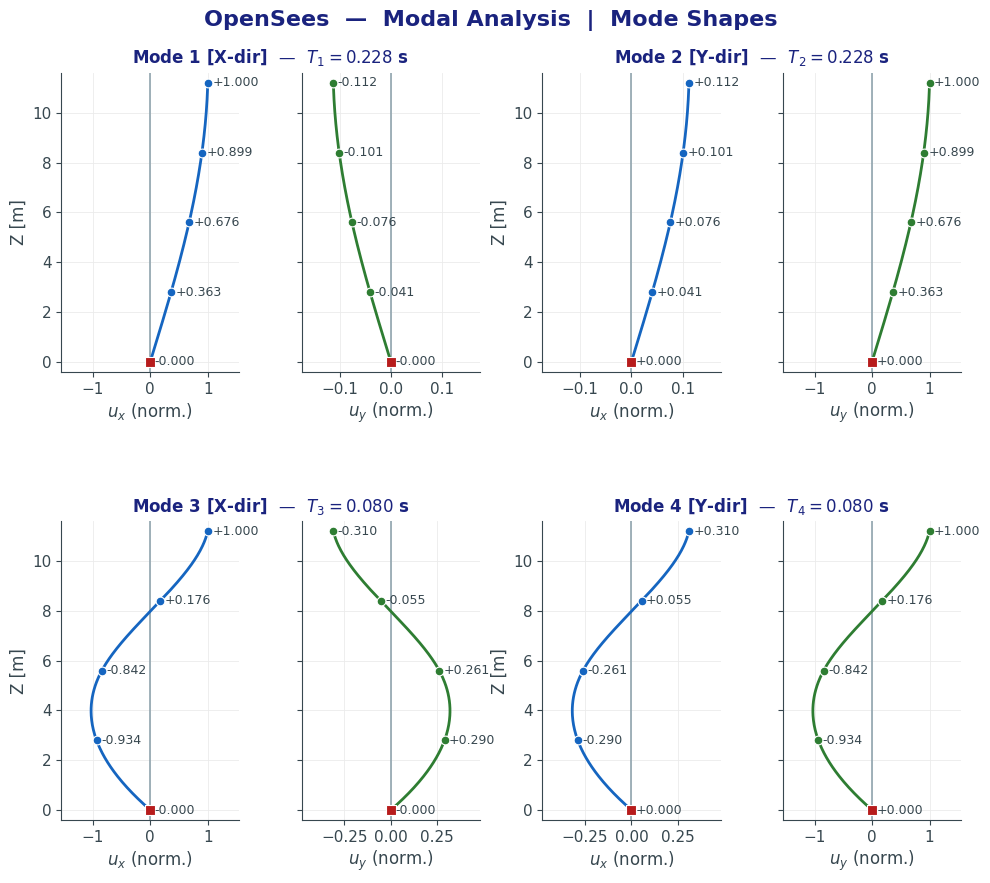

In [5]:
# Do modal analysis
num_modes = 4
T, phi = model.do_modal_analysis(
    num_modes=num_modes,  # Get N-modes
    pFlag=True,  # Prints modal analysis report
    plot_modes=True,  # Plots modal analysis results
    export_path="out/modal_analysis.png",
)  # Exports modal analysis results

## Run Static (Monotonic) Pushover Analysis ##

`do_spo_analysis` runs a displacement-controlled static pushover by incrementally applying a lateral load pattern (`phi`) up to a target displacement of `ref_disp × disp_scale_factor`. It returns a results dictionary containing floor displacements (`spo_disps`), base shear (`spo_rxn`), spring deformations and forces, and inter-storey drift ratio histories. When `save_animation_path` is provided, a synchronised three-panel animation (deformed shape, pushover curve, base shear vs. MIDR) is exported alongside the results.

In [6]:
# Define pushover analysis parameters
ref_disp = sdof_capacity[1,0]*meta['gamma_real']            # Reference displacement
disp_scale_factor = 15                                      # Multiplier of the reference displacement
push_dir = 1                                                # Push direction (for X-direction:1, for Y-direction=2)

push_pattern = mdof_phi.tolist()                            # Normalised first mode

# Do gravity analysis
model.do_gravity_analysis()                                 # Do gravity analysis

# Do pushover analysis
results = model.do_spo_analysis(
    ref_disp,
    disp_scale_factor,
    push_dir,
    push_pattern,
    pFlag=False,
    num_steps=200,
    ansys_soe='BandGeneral',
    constraints_handler='Transformation',
    numberer='RCM',
    test_type='EnergyIncr',
    init_tol=1.0e-5,
    init_iter=1000,
    algorithm_type='KrylovNewton',
    # Export animation of SPO when setting path, set to None if you opt not to
    save_animation_path='out/spo_animation.gif')

print('ANALYSIS COMPLETED!')

------ ANALYSIS FAILED! --------
Stopped because of load factor below zero
Saving SPO animation (19 frames) to: out/spo_animation.gif
ANALYSIS COMPLETED!


### Explore the Results of the Static Pushover Analysis ###

In [7]:
# Unpack the SPO results
spo_disps = results['spo_disps']          # Displacements at each control node (i.e., floor)
spo_rxn = results['spo_rxn']            # Reaction at base (Base shear)
# Displacements in nonlinear springs (i.e., zero-length elements)
spo_disps_spring = results['spo_disps_spring']
# Forces in nonlinear springs (i.e., zero-length elements)
spo_forces_spring = results['spo_forces_spring']
spo_idr = results['spo_idr']            # Interstorey drift ratios
spo_midr = results['spo_midr']           # Maximum interstorey drifts

![cpo_animation](out/spo_animation.gif)

## Run Nonlinear Time-History Analysis via Modified Cloud Analysis ##

### Define Directories ###

In [8]:
# Define the directory of the ground-motion records
gm_directory = './in/records/global'

# Define the main output directory
nrha_directory = './out/analysis'
os.makedirs(nrha_directory, exist_ok=True)

### Load Pre-Processed Intensity Measures ###

The records used in this demonstration are derived from the datasets utilized in the development of the 2026 Global Seismic Vulnerability Model. These records are available on the model's dedicated documentation page: https://docs.openquake.org/vulnerability/ground_motion_records.html 

In [9]:
# Import the intensity measure dictionary (output from "IntensityMeasureProcessing" demo)
ims = import_from_pkl(os.path.join(gm_directory, 'ims.pkl'))

### Set Up, Run and Export Cloud Analysis ###

In the next code snippet, a cloud-based nonlinear time-history analysis is performed on the pre-calibrated stick model using a suite of 700 recorded ground-motion time histories representing various tectonic region types and curated from international databases such as NGA-W2, ESM and Kik-Net.

For each ground-motion record, the MDOF model is compiled, gravity-loaded, and subjected to modal analysis to extract its dynamic properties. The ground motion is then applied through NLTHA using consistent time-stepping, appropriate unit scaling, and specified damping.

The analysis extracts key engineering demand parameters (EDPs), including peak storey drifts, peak floor accelerations, and peak floor displacements along the building height. Maximum response values, together with their associated directions and locations, are also recorded. Numerical convergence is monitored through a convergence index.

All response quantities are stored for each record and aggregated into a structured dataset, which is exported for subsequent cloud regression, fragility development, and vulnerability analysis.

In [10]:
# Inherent damping
mdof_damping = 0.05

# Initialise MDOF storage lists
conv_index_list = []               # List for convergence indices
# List for peak floor displacement (returns all peak values along the building height)
peak_disp_list = []
# List for peak storey drift (returns all peak values along the building height)
peak_drift_list = []
# List for peak floor acceleration (returns all peak values along the building height)
peak_accel_list = []
max_peak_drift_list = []           # List for maximum peak storey drift (returns the maximum value)
max_peak_drift_dir_list = []       # List for maximum peak storey drift directions
max_peak_drift_loc_list = []       # List for maximum peak storey drift locations
# List for maximum peak floor acceleration (returns the maximum value)
max_peak_accel_list = []
max_peak_accel_dir_list = []       # List for maximum peak floor acceleration directions
max_peak_accel_loc_list = []       # List for maximum peak floor acceleration locations
total_hyst_energy_list = []        # List for total hysteretic energy dissipated
storey_hyst_energy_list = []       # List for storey-based hysteretic energy dissipated

# Loop over ground-motion records, compile MDOF model and run NLTHA
# The set of ground-motion records utilized correspond to the acceleration
# time-histories of the European Seismic Risk Model 2020 (Crowley et al.)
# Sort the ground-motion records alphanumerically
gmrs = sorted_alphanumeric(os.listdir(os.path.join(gm_directory, 'acc')))
# Sort the ground-motion time-step files alphanumerically
dts = sorted_alphanumeric(os.listdir(os.path.join(gm_directory, 'dts')))

# Run the analysis
for i in range(len(gmrs)):
    # Print post-processing iteration
    print('================================================================')
    print('============== Analysing: {:d} out of {:d} =================='.format(i + 1, len(gmrs)))
    print('================================================================')

    # Compile the MDOF model
    model = modeller(
        number_storeys,
        storey_heights,
        floor_masses,
        storey_drifts,
        storey_forces * units.g,
        mdof_degradation)  # Initialise the class (Build the model)

    # Compile the MDOF model
    model.compile_model()

    # Do gravity analysis
    model.do_gravity_analysis()

    # Do modal analysis and get period of vibration (Essential step for running NLTHA)
    T, phi = model.do_modal_analysis(num_modes=get_num_modes(number_storeys), plot_modes=False)

    # Define ground motion objects
    # Ground-motion record names
    fnames = [os.path.join(gm_directory, 'acc', f'{gmrs[i]}')]
    # Ground-motion time-step names
    fdts = os.path.join(gm_directory, 'dts', f'{dts[i]}')
    _csv = pd.read_csv(fdts, header=None)
    _col = _csv.columns[0]
    dt_gm = _csv[_col].loc[1] - _csv[_col].loc[0]  # Ground-motion time-step
    # Ground-motion duration
    t_max = pd.read_csv(fdts)[pd.read_csv(fdts).columns[0]].iloc[-1]

    # Define analysis params and do NLTHA
    # Set the analysis time-step
    dt_ansys = dt_gm
    # Set the scaling factor (if records are in g, a scaling factor of 9.81
    # m/s2 must be used to be consistent with opensees)
    sf = units.g
    (control_nodes, conv_index, peak_drift, peak_accel,
     max_peak_drift, max_peak_drift_dir, max_peak_drift_loc,
     max_peak_accel, max_peak_accel_dir, max_peak_accel_loc,
     peak_disp, storey_hyst_energy,
     total_hyst_energy) = model.do_nrha_analysis(
        fnames, dt_gm, sf, t_max, dt_ansys, pFlag=False, xi=mdof_damping)

    # Store the analysis
    conv_index_list.append(conv_index)
    peak_drift_list.append(peak_drift)
    peak_accel_list.append(peak_accel)
    peak_disp_list.append(peak_disp)
    max_peak_drift_list.append(max_peak_drift)
    max_peak_drift_dir_list.append(max_peak_drift_dir)
    max_peak_drift_loc_list.append(max_peak_drift_loc)
    max_peak_accel_list.append(max_peak_accel)
    max_peak_accel_dir_list.append(max_peak_accel_dir)
    max_peak_accel_loc_list.append(max_peak_accel_loc)
    storey_hyst_energy_list.append(storey_hyst_energy)
    total_hyst_energy_list.append(total_hyst_energy)

# Store the analysis results in a dictionary
ansys_dict = {}
labels = ['T', 'control_nodes', 'conv_index_list',
          'peak_drift_list', 'peak_accel_list',
          'max_peak_drift_list', 'max_peak_drift_dir_list',
          'max_peak_drift_loc_list', 'max_peak_accel_list',
          'max_peak_accel_dir_list', 'max_peak_accel_loc_list',
          'peak_disp_list', 'total_hyst_energy_list', 'storey_hyst_energy_list']

for i, label in enumerate(labels):
    ansys_dict[label] = vars()[f'{label}']

# Export the analysis output variable to a pickle file using the
# "export_to_pkl" function from "utilities"
export_to_pkl(os.path.join(nrha_directory, 'cloud_out.pkl'), ansys_dict)

# Print statement
print('ANALYSIS COMPLETED!')

============== Analysing: 1 out of 700 ==================
FAILED at 10.120: Trying half time-step.
------ ANALYSIS FAILED --------
============== Analysing: 2 out of 700 ==================
------ ANALYSIS FAILED --------
============== Analysing: 3 out of 700 ==================
------ ANALYSIS FAILED --------
============== Analysing: 4 out of 700 ==================


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2003 has L= 2.8, which is greater than the tolerance
after: 50 iterations  current Norm: 0.000231913 (max: 1e-06, Norm deltaR: 0.716583)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 10.14
OpenSees > analyze failed, returned: -3 error flag
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2003 has L= 2

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
============== Analysing: 5 out of 700 ==================
------ ANALYSIS FAILED --------
============== Analysing: 6 out of 700 ==================


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2003 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2003 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
============== Analysing: 7 out of 700 ==================


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2003 has L= 2.8, which is greater than the tolerance


------ ANALYSIS FAILED --------
============== Analysing: 695 out of 700 ==================
------ ANALYSIS FAILED --------
============== Analysing: 696 out of 700 ==================
------ ANALYSIS FAILED --------
============== Analysing: 697 out of 700 ==================
------ ANALYSIS FAILED --------
============== Analysing: 698 out of 700 ==================
------ ANALYSIS FAILED --------
============== Analysing: 699 out of 700 ==================


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2003 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2003 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 2.8, wh

------ ANALYSIS FAILED --------
============== Analysing: 700 out of 700 ==================
------ ANALYSIS FAILED --------
ANALYSIS COMPLETED!


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2003 has L= 2.8, which is greater than the tolerance


## Probabilistic Seismic Demand Modelling and Fragility Function Fitting ##

### The Probabilistic Seismic Demand Model: IM-EDP Relationship

#### Step 1: Classical Cloud Analysis 

**Cloud Analysis (CA)** [1,2,3] involves performing nonlinear time-history analyses using **a set of "as-recorded" ground motions without scaling**. A probabilistic seismic demand model (PSDM) characterising the relationshipbetween the engineering demand parameters (EDP) resulting from CA and the level of ground-shaking intensity measure (IM) can be simply fitted through linear regression in the logarithmic space. The PSDM can be used then to derive fragility functions that describe the probability of exceeding different damage states, given the IM level. This method can also be modified, as proposed in [1,2,3], to account for **structural collapse cases through Logistic regression and probabilistic combination**. This is called the **Modified Cloud Analysis (MCA)** approach.

The EDP–IM relationship is first expressed as:

$$
EDP = a \, IM^{\,b}
$$

Applying a logarithmic transformation yields a linear regression model:

$$
\ln(EDP) = \ln(a) + b \ln(IM)
$$

where:

- $\ln(a)$ and $b$ are the regression intercept and slope, estimated via least-squares fitting,  

The record-to-record uncertainty, expressed as the logarithmic standard deviation of the EDP conditioned on the IM, is given by:

$$
\beta_{EDP \,|\, IM}
\approx
\sqrt{
\frac{
\sum_{i=1}^{n}
\left[
\ln(EDP_i) - \ln(a \, IM_i^{\,b})
\right]^2
}
{n - 2}
}
$$

where $n$ is the number of non-collapse ground-motion records.


#### Step 2: Modified Cloud Analysis and Treatment of Collapse Cases

In nonlinear dynamic analyses, numerical non-convergence or excessive response may indicate structural collapse, commonly defined by exceeding a collapse threshold $EDP \ge EDP_C$. Such cases cannot be directly included in classical cloud regression due to undefined or unbounded EDP values.

Using the Total Probability Theorem, the probability of exceeding a damage state $DS$ at a given intensity level is decomposed into two mutually exclusive events: collapse (C) and no-collapse (NC):

$$
P(DS \,|\, IM)
=
P(DS \,|\, NC, IM)\,P(NC \,|\, IM)
+
P(DS \,|\, C, IM)\,P(C \,|\, IM)
$$

Since exceeding any damage state is guaranteed given collapse:

$$
P(DS \,|\, C, IM) = 1
$$

the expression simplifies to:

$$
P(DS \,|\, IM)
=
P(DS \,|\, NC, IM)\,[1 - P(C \,|\, IM)]
+
P(C \,|\, IM)
$$

where:

- $P(DS \,|\, NC, IM)$ is the fragility derived from cloud regression using only non-collapse data,  
- $P(C \,|\, IM)$ is the probability of collapse.


Subsequently, the probability of collapse is estimated using Logistic regression as a function of the intensity measure:

$$
P(C \,|\, IM)
=
\frac{1}
{1 + \exp\!\left[-\left(\alpha_0 + \alpha_1 \ln(IM)\right)\right]}
$$

where $\alpha_0$ and $\alpha_1$ are regression coefficients fitted to collapse / non-collapse outcomes.


#### Note on Statistical Stabilisation via Bootstrapping

Modified Cloud Analysis is often based on a limited number of ground-motion records, which can lead to numerical instability and sensitivity to outliers. 
**Bootstrapping** is employed to improve robustness. The procedure to pre-process MCA data using bootstrapping is outlined as such:

1. **Resampling**: Generate $N$ bootstrap datasets (e.g., $N = 200$) by random sampling with replacement from the original dataset.

2. **Estimation**: For each bootstrap sample, perform cloud regression on non-collapse records and Logistic regression for collapse probability.

3. **Aggregation**: Compute the mean probability of exceedance across all bootstrap realizations.

The main benefits of using bootstrapping as a pre-processing step are reducing the influence of individual extreme ground motions,  produces a smoother transition in the fragility curve as intensity approaches collapse-dominated areas, enables estimation of epistemic uncertainty through percentile bounds (e.g., 16th and 84th percentiles). This combined framework yields statistically stable and physically consistent fragility functions that explicitly account for both demand variability and collapse phenomena within the Modified Cloud Analysis methodology.


### Fragility Function Derivation

Fragility functions describe the probability that a structure will reach or exceed a given damage state as a function of an intensity measure (IM). In this framework, fragility functions are assumed to follow a lognormal distribution, which is commonly adopted in seismic risk assessment due to its ability to capture uncertainty in structural response.

Let $P(DS \ge ds_i \mid IM)$ denote the probability that damage state $ds_i$ is exceeded at a given intensity measure level $IM$. Under the lognormal assumption, this probability is expressed as

$$
P(DS \ge ds_i \mid IM) =
\Phi \left(
\frac{\ln(IM) - \ln(\theta_{ds_i})}{\beta_{ds_i}^{\text{total}}}
\right)
$$

where:

* $\theta_{ds_i}$ is the median intensity measure corresponding to damage state $ds_i$
* $\beta_{ds_i}^{\text{total}}$ is the total logarithmic standard deviation for damage state $ds_i$
* $\Phi(\cdot)$ denotes the standard normal cumulative distribution function

The total dispersion $\beta_{ds_i}^{\text{total}}$ accounts for multiple sources of uncertainty and is computed as the root sum of squares of the individual components:

$$
\beta_{ds_i}^{\text{total}} =
\sqrt{
\beta_{\text{record-to-record}}^2 +
\beta_{\text{building-to-building}}^2 +
\beta_{\text{DS}}^2
}
$$

where:

* $\beta_{\text{record-to-record}}$ (or $\beta_{\text{EDP|IM}}$) represents variability due to ground motion record-to-record uncertainty
* $\beta_{\text{building-to-building}}$ captures variability in structural properties across nominally similar buildings
* $\beta_{\text{DS}}$ represents uncertainty associated with the definition and threshold of the damage state

This formulation ensures that the fragility functions consistently incorporate the combined effects of aleatory and epistemic uncertainties across all damage states.

In [11]:
# Intensity measure to use for postprocessing cloud analyses
IMT = 'SA(0.3)'

# Import the intensity measure levels associated the PGA
imls = ims[f'{IMT}']

# Import the engineering demand parameters (i.e., maximum peak storey
# drifts) from the analysis dictionary
edps = ansys_dict['max_peak_drift_list']

# Damage thresholds (Drift-based values in rad)
damage_thresholds =     [0.002593985,0.005459774,0.008412406,0.011278195]

# The lower limit to be applied for censoring edp values
# (Recommendation: below 0.1 the minimum threshold for slight damage
# is considered a negligible case)
lower_limit = 0.1 * damage_thresholds[0]

# The upper limit to be applied for censoring edp values
# (Recommendation: above 1.5 the maximum threshold is considered a collapse case)
censored_limit = 1.5 * damage_thresholds[-1]

# The modelling uncertainty due to differences in actual response
# properties among nominally similar buildings
sigma_build2build = 0.3

# The uncertainty in damage state threshold since the demand-based damage thresholds are estimated
# based on limited empirical data and/or expert judgment
sigma_ds = 0.3

# Initialise the postprocessor class
pp = postprocessor()

# Process modified cloud analysis results using the "process_mca_results" function
# with bootstrap resampling to quantify parameter uncertainty.
# The output will be automatically stored in a dictionary
cloud_dict_bootstrap = pp.process_mca_results(
    imls,                                   # Intensity measure levels
    edps,                                   # Engineering demand parameters
    damage_thresholds,                      # Demand-based damage thresholds
    lower_limit,                            # Lower censoring limit
    censored_limit,                         # Upper censoring limit (collapse threshold)
    sigma_build2build=sigma_build2build,    # Modelling uncertainty
    sigma_ds=sigma_ds,                      # Uncertainty in DS threshold
    cloud_method='bootstrap')               # Bootstrap resampling (default)

### Visualise Analysis Results, Probabilistic Seismic Demand Models, and Fragility Functions ###

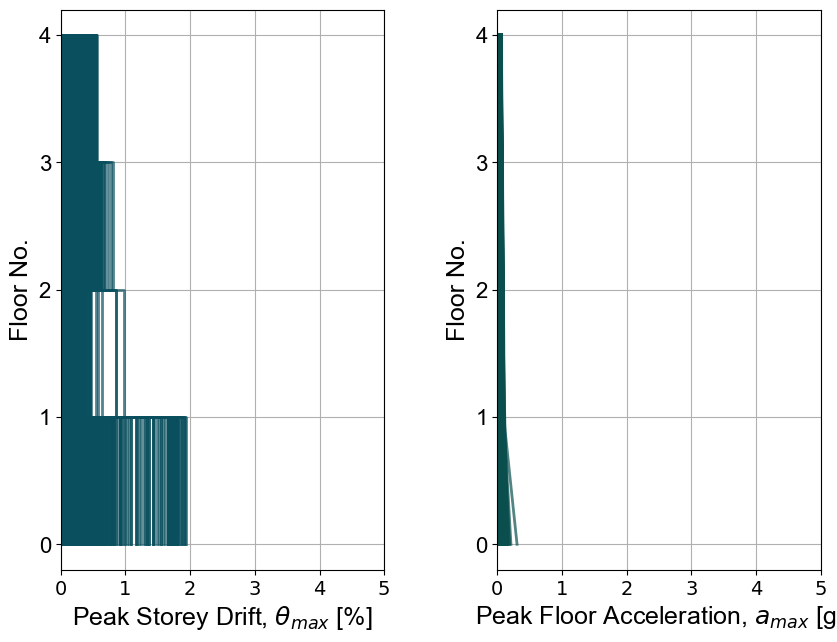

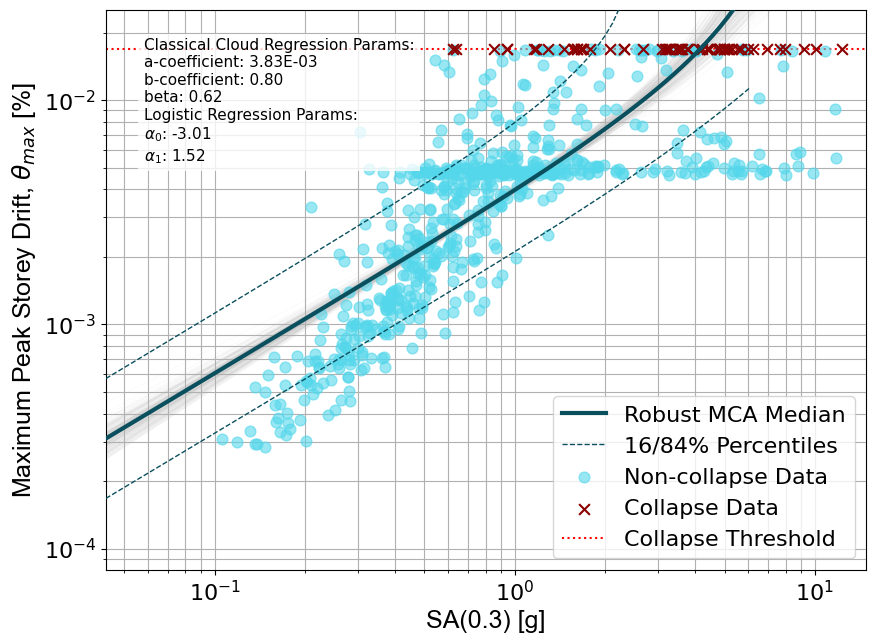

In [12]:
# Initialise the plotter class
pl = plotter()

# Visualise the seismic demands: the y-axis values for drifts and
# accelerations are converted to % and g automatically by the plotter
pl.plot_demand_profiles(ansys_dict['peak_drift_list'],   # Drifts
                        ansys_dict['peak_accel_list'],   # Accelerations
                        ansys_dict['control_nodes'],     # Control nodes
                        pFlag=True,
                        export_path='out/demand_profiles.png')

# Visualise the Modified Cloud Analysis (Bootstrap) results
pl.plot_mca_analysis(cloud_dict_bootstrap,    # Bootstrap MCA dictionary
                     f'{IMT} [g]',            # Intensity measure label
                     r'Maximum Peak Storey Drift, $\theta_{max}$ [%]',
                     pFlag=True,
                     export_path='out/cloud_analysis_bootstrap.png')


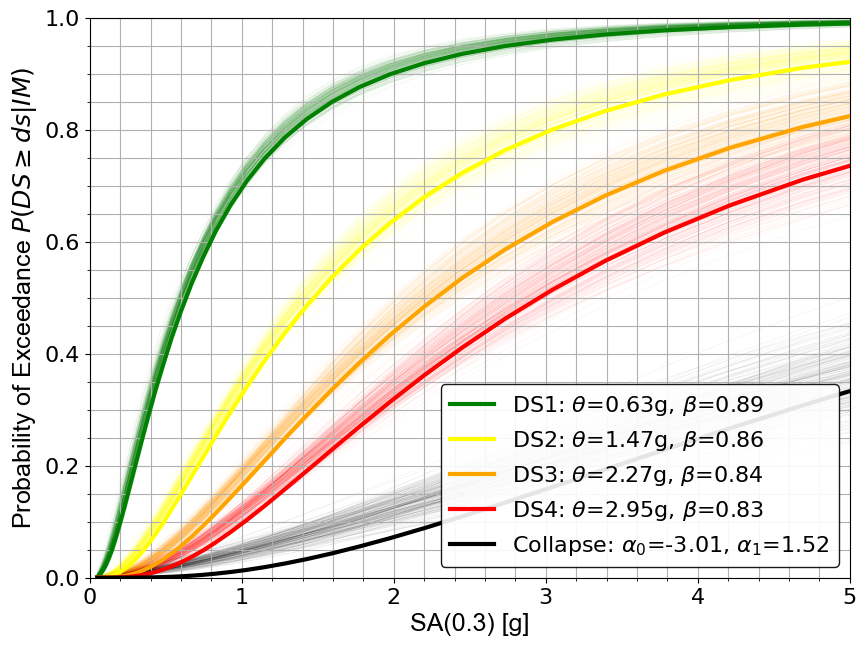

In [13]:
# Visualise the fragility functions from Bootstrap MCA
xlims = [0, 5]
ylims = [0, 1]
pl.plot_fragility_from_mca(cloud_dict_bootstrap,  # Bootstrap MCA dictionary
                           f'{IMT} [g]',
                           xlims,
                           ylims,
                           plot_bootstrap=True,
                           cloud_method='bootstrap',
                           pFlag=True,
                           export_path='out/fragility_curves.png')

## Vulnerability Functions (based on Fragility and Damage-to-Loss Models) ##

### Expected Loss Ratio (Mean Damage Ratio)

The vulnerability function expresses the expected loss ratio as a function of an intensity measure level (IM) and is obtained by convolving fragility functions with damage-to-loss ratios associated with each damage state.
Let $P(DS = ds_i \mid IM)$ denote the probability of the structure being in damage state $ds_i$ at a given intensity measure level $IM$, and let $\mu_{LR,i}$ be the mean loss ratio associated with that damage state. The expected loss ratio at intensity level $IM$, denoted as $E[LR \mid IM]$, is defined as

$$
E[LR \mid IM] = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM) \cdot \mu_{LR,i}
$$

where:

* $N_{DS}$ is the total number of discrete damage states
* $P(DS = ds_i \mid IM)$ is derived from the fragility functions
* $\mu_{LR,i}$ is the mean loss ratio associated with damage state $ds_i$


#### Step 1: Calculate Damage-State Probabilities (i.e., Probabilities of Occurrence) from Fragility Functions

Fragility functions are commonly expressed in terms of probabilities of exceedance. The probability of being in a specific damage state is computed as

$$
P(DS = ds_i \mid IM) =
\begin{cases}
P(DS \ge ds_i \mid IM) - P(DS \ge ds_{i+1} \mid IM), & i < N_{DS} \\
P(DS \ge ds_{N_{DS}} \mid IM), & i = N_{DS}
\end{cases}
$$

Assuming lognormal fragility functions, the probability of exceeding damage state $ds_i$ is given by

$$
P(DS \ge ds_i \mid IM) = 
\Phi\left(
\frac{\ln(IM) - \ln(\mu_{ds_i})}
{\beta_{ds_i}^{\text{total}}}
\right)
$$

where:

* $\mu_{ds_i}$ is the median intensity measure corresponding to damage state $ds_i$
* $\beta_{ds_i}^{\text{total}}$ is the total logarithmic standard deviation
* $\Phi(\cdot)$ is the standard normal cumulative distribution function

The total dispersion is computed as

$$
\beta_{ds_i}^{\text{total}} = 
\sqrt{
\beta_{\text{record-to-record}}^2
+
\beta_{\text{building-to-building}}^2
+
\beta_{\text{DS}}^2
}
$$

where:

* $\beta_{\text{record-to-record}}$ (or $\beta_{\text{EDP}\mid IM}$) represents ground-motion variability
* $\beta_{\text{building-to-building}}$ captures model and structural variability
* $\beta_{\text{DS}}$ represents uncertainty in damage-state definition and thresholds


#### Step 2: Calculation of Uncertainty in Expected Loss

The uncertainty in the expected loss ratio given IM level can be quantified by explicitly propagating uncertainty through the convolution of damage-state probabilities and damage-to-loss ratios. In this formulation, fragility functions account for uncertainty in structural response and damage-state thresholds, while additional uncertainty arises from variability in the damage-to-loss ratios associated with each damage state. The expected loss ratio conditional on $IM$ is given by

$$
E[LR \mid IM] = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM) \cdot \mu_{LR,i}
$$

Assuming the loss ratio conditional on each damage state is an independent random variable with coefficient of variation $\mathrm{COV}_{LR,i}$, the variance of the loss ratio conditional on $IM$ is computed using the **law of total variance**:

$$
\mathrm{Var}(LR \mid IM) = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM)
\left[
\sigma_{LR,i}^2
+
\left(
\mu_{LR,i} - E[LR \mid IM]
\right)^2
\right]
$$

where

$$
\sigma_{LR,i} =
\mathrm{COV}_{LR,i} \cdot \mu_{LR,i}
$$

The coefficient of variation of the loss ratio conditional on the intensity measure is then computed as

$$
\mathrm{COV}(LR \mid IM) = 
\frac{
\sqrt{\mathrm{Var}(LR \mid IM)}
}{
E[LR \mid IM]
}
$$

This formulation captures both:

* uncertainty **within damage states** due to variability in damage-to-loss ratios, and
* uncertainty due to **damage-state mixing** as intensity varies.

In [14]:
# Define consequence model to relate structural damage to a decision
# variable (i.e., expected loss ratio)
consequence_model = [0.05, 0.20, 0.60, 1.00]  # damage-to-loss ratios

# Define the uncertainty associated with each damage-to-loss ratio via coefficients of variation
consequence_cov = [0.30, 0.25, 0.20, 0.00]

# Calculate the structural vulnerability function (using the explicit method)
poes = cloud_dict_bootstrap['fragility']['poes'][:, :4]  # Use poes output (columns 1 to 4 > DS1 to DS4)
structural_vulnerability = pp.calculate_vulnerability_function(
    poes,
    consequence_model,
    # The consequence model representing the normalised loss ratios
    # per damage state
    cov_consequence=consequence_cov,
    # The coefficient of variation model representing the uncertainty
    # around the loss ratios per damage state
    uncertainty=True)
    # Set uncertainty equal to True to calculate COV of the Beta Distribution

### Plot the Vulnerability Functions with Uncertainty Visualisation ###

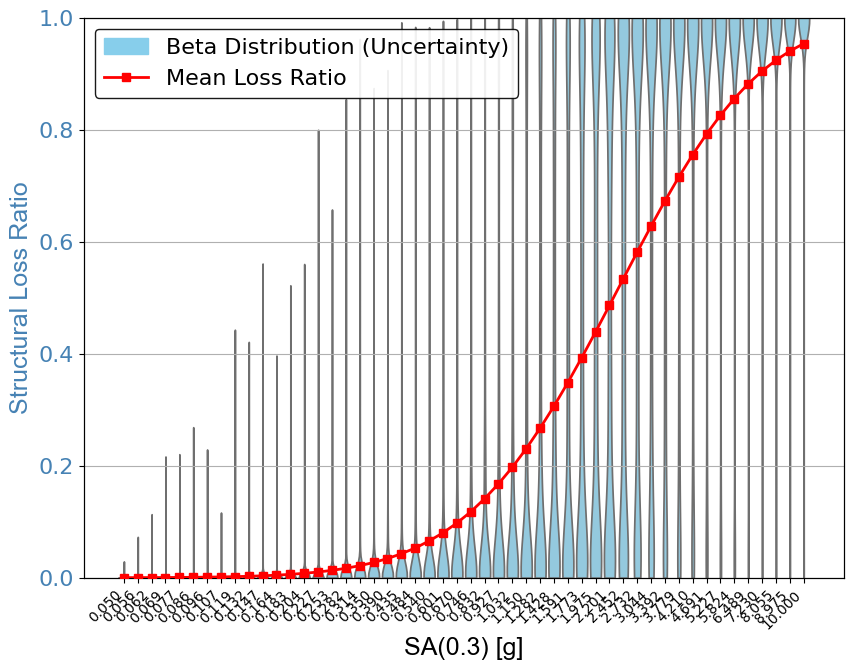

In [15]:
# Plot the structural vulnerability function from the explicit COV method
pl.plot_vulnerability_function(structural_vulnerability['IML'],
                               structural_vulnerability['Loss'],
                               structural_vulnerability['COV'],
                               imt_label=f'{IMT} [g]',
                               loss_label='Structural Loss Ratio',
                               pFlag=True,
                               export_path='out/vulnerability_curve.png')

### Average Annual Loss Ratio ###

In performance-based earthquake engineering, the **Average Annual Loss Ratio (AALR)** quantifies the expected loss ratio due to earthquake-induced damage over one year, accounting for both the **probabilistic hazard** at a site and the vulnerability of the structure.

Mathematically, the AALR is computed as:

$$
\mathrm{AALR} = \int_0^{\infty} LR(IM) \, \frac{d\lambda(IM)}{dIM} \, dIM
$$

where:

* $LR(IM)$ is the **loss ratio** conditional on an intensity measure level (IM), obtained from the vulnerability function.
* $\lambda(IM)$ is the **annual frequency of exceedance** of intensity measure $IM$, derived from the seismic hazard curve.
* $\frac{d\lambda(IM)}{dIM} \, dIM$ represents the probability that the intensity measure occurs within a differential interval $[IM, IM+dIM]$.

In practice, the AALR is approximated using **discrete intensity levels** and **finite differences** from the hazard curve:

$$
\mathrm{AALR} \approx \sum_{i=1}^{N} LR(IM_i) \, \big(\lambda(IM_i) - \lambda(IM_{i+1})\big)
$$

The next code snippet will produce AALRs considering the same structure but placed fictitiously in different cities with distinct hazard features. The hazard curves (annual rate of exceedance of SA(0.3s)) are read from `in/hazard_curves.csv`.


In [16]:
# Import the hazard curves
hazard_in = pd.read_csv('in/hazard_curves.csv')

# Visualise the hazard file expressing the annual rate of exceedance given
# increasing intensity levels of SA(0.3s) and considering different cities
hazard_in.head()

# Prepare the Vulnerability Array: We stack 'IML' and 'Loss' into a 2D array (N x 2)
vulnerability_array = structural_vulnerability[['IML', 'Loss']].to_numpy()

# Extract Cities from the Hazard DataFrame (skipping the first column of IMs)
cities = hazard_in.columns[1:]

# Dictionary to store results
aal_results = {}

# Calculate AALR for each city
for city in cities:

    # Create the hazard array for the current city
    # Column 0: Intensity (SA(0.3s)), Column 1: Annual Rate of Exceedance for that city
    hazard_array = hazard_in.iloc[:, [0, hazard_in.columns.get_loc(city)]].to_numpy()

    # Calculate AALR using the "calculate_risk" method
    current_AAL = pp.calculate_risk(input_array=vulnerability_array,
                                    hazard_array=hazard_array,
                                    return_period=1.0,
                                    max_return_period=5000.0)

    aal_results[city] = current_AAL
    print(f"City: {city:15s} | AALR: {current_AAL * 100:.6f}%")


City: Vancouver       | AALR: 0.041285%
City: San Salvador    | AALR: 0.517436%
City: Athens          | AALR: 0.235419%
City: Istanbul        | AALR: 0.290969%
City: Lisbon          | AALR: 0.020833%
City: Beirut          | AALR: 0.007186%
City: Wellington      | AALR: 0.392142%


### Average Annual Collapse Probability ###

Similarly, the **Average Annual Collapse Probability (AACP)** quantifies the probability that a structure will experience **collapse** in a given year, accounting for both the **probabilistic seismic hazard** and the **collapse fragility** of the structure:

$$
\mathrm{AACP} = \int_0^{\infty} P_\text{collapse}(IM) \, \frac{d\lambda(IM)}{dIM} \, dIM
\approx \sum_{i=1}^{N} P_\text{collapse}(IM_i) \, \big(\lambda(IM_i) - \lambda(IM_{i+1})\big)
$$

where $P_\text{collapse}(IM)$ is the probability of collapse conditional on the intensity measure level, taken here as the exceedance probability of the last (most severe) damage state of the fragility functions.

The next code snippet calculates AACPs for the same structure located in different cities, each with distinct seismic hazard characteristics.


In [17]:
# Prepare the Fragility Array (AACP refers to collapse, the last damage state column)
fragility_array = np.column_stack(
    (cloud_dict_bootstrap['fragility']['intensities'],
     cloud_dict_bootstrap['fragility']['poes'][:, -1]))

# Dictionary to store results
aacp_results = {}

# Calculate AACP for each city
for city in cities:

    # Create the hazard array: Col 0 is IM, Col 1 is the specific city rates
    hazard_array = hazard_in.iloc[:, [0, hazard_in.columns.get_loc(city)]].to_numpy()

    # Calculate AACP using the "calculate_risk" method
    current_AACP = pp.calculate_risk(input_array=fragility_array,
                                     hazard_array=hazard_array,
                                     return_period=1.0,
                                     max_return_period=5000.0)

    aacp_results[city] = current_AACP
    print(f"City: {city:15s} | AACP: {current_AACP * 100:.6f}%")


City: Vancouver       | AACP: 0.000916%
City: San Salvador    | AACP: 0.033229%
City: Athens          | AACP: 0.015400%
City: Istanbul        | AACP: 0.021788%
City: Lisbon          | AACP: 0.000327%
City: Beirut          | AACP: 0.000039%
City: Wellington      | AACP: 0.036212%


### Figure: Seismic Hazard, Average Annual Loss Ratio and Collapse Probability per City ###

The figure below pairs the hazard curves of the selected cities (a) with the resulting AALRs (b) and AACPs (c), and is exported in vector (PDF) and high-resolution raster (PNG) formats for inclusion in publications. Each city keeps the same colour and line style in all panels, and bars share the same city order in (b) and (c).

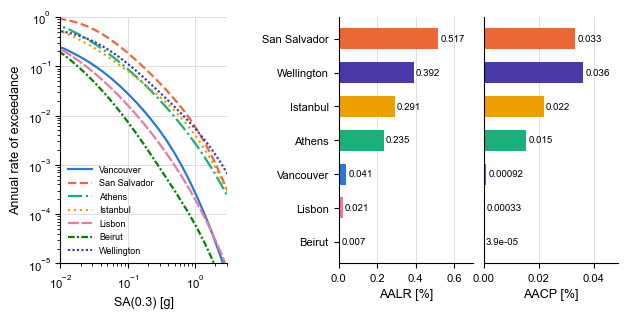

In [20]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Journal-style settings (single figure of two panels, ~double-column width)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,          # embed TrueType fonts (editable text in PDF)
})

# Fixed colour and line-style per city (identity is never colour-alone)
city_colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]
city_styles = ["-", "--", "-.", ":", (0, (5, 1)), (0, (3, 1, 1, 1)), (0, (1, 1))]
style = {c: (city_colors[k % 7], city_styles[k % 7]) for k, c in enumerate(cities)}

fig = plt.figure(figsize=(7.2, 3.2))
gs_main = fig.add_gridspec(1, 2, width_ratios=[1.25, 2.1], wspace=0.5)
gs_bars = gs_main[1].subgridspec(1, 2, wspace=0.08)
ax_h = fig.add_subplot(gs_main[0])
ax_b = fig.add_subplot(gs_bars[0])
ax_c = fig.add_subplot(gs_bars[1])

# (a) Hazard curves
for city in cities:
    ax_h.plot(hazard_in.iloc[:, 0], hazard_in[city], color=style[city][0],
              ls=style[city][1], lw=1.6, label=city)
ax_h.set_xscale("log")
ax_h.set_yscale("log")
ax_h.set_xlim(0.01, 3)
ax_h.set_ylim(1e-5, 1)
ax_h.set_xlabel(f"{IMT} [g]")
ax_h.set_ylabel("Annual rate of exceedance")
ax_h.grid(True, which="major", color="0.85", lw=0.6)
ax_h.legend(loc="lower left", frameon=False, handlelength=2.6, fontsize=6.5)

# Cities sorted by AALR (same order in (b) and (c))
order = sorted(aal_results, key=aal_results.get)


def bar_panel(ax, results, xlabel, title, show_names, fmt):
    vals = [results[c] * 100 for c in order]
    bars = ax.barh(order, vals, color=[style[c][0] for c in order], height=0.62)
    for b, v in zip(bars, vals):
        ax.text(v + max(vals) * 0.02, b.get_y() + b.get_height() / 2,
                format(v, fmt), va="center", ha="left", fontsize=7)
    ax.set_xlim(0, max(vals) * 1.35)
    ax.set_xlabel(xlabel)
    ax.grid(True, axis="x", color="0.85", lw=0.6)
    ax.set_axisbelow(True)
    ax.set_title(title, loc="left")
    if not show_names:
        ax.tick_params(axis="y", labelleft=False, length=0)


# (b) AALR and (c) AACP per city
bar_panel(ax_b, aal_results, "AALR [%]", "", True, ".3f")
bar_panel(ax_c, aacp_results, "AACP [%]", "", False, ".2g")

fig.savefig("out/aalr_aacp_cities.png", dpi=600, bbox_inches="tight")
plt.show()
